# Task 2: ARIMA/SARIMA Time Series Forecasting for Tesla (TSLA)

**Project:** Portfolio Management Optimization for GMF Investments  
**Author:** Senior Quantitative Analyst  
**Date:** January 2026

---

## 📋 Objective

Build a time series forecasting model using **ARIMA/SARIMA** to predict Tesla (TSLA) stock prices.

### Deliverables:
1. Stationarity analysis with ADF/KPSS tests
2. Parameter selection using ACF/PACF and auto_arima
3. ARIMA/SARIMA model fitting and diagnostics
4. Forecasting with confidence intervals
5. Performance evaluation (MAE, RMSE, MAPE)
6. Discussion of limitations and EMH implications

### Data Split:
- **Training:** 2015-01-01 to 2024-12-31
- **Testing:** 2025-01-01 to 2026-01-15

---

## 📦 Setup and Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Data extraction
import yfinance as yf

# Time series analysis
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Auto ARIMA
from pmdarima import auto_arima

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


---

## 📊 STEP 1: Data Loading and Preparation

We extract Tesla (TSLA) stock data using `yfinance` and prepare it for time series modeling.

**Key Steps:**
1. Download TSLA historical data
2. Extract Adjusted Close prices
3. Create train/test split maintaining chronological order
4. Visualize the data split

In [2]:
# Download Tesla stock data
print("Downloading TSLA data...")
tsla_raw = yf.download('TSLA', start='2015-01-01', end='2026-01-28', progress=False)

# Extract the closing price
# Logic to handle different yfinance return formats (MultiIndex vs Single Index)
if isinstance(tsla_raw.columns, pd.MultiIndex):
    # Check for Adj Close then Close
    if 'Adj Close' in tsla_raw.columns.get_level_values(0):
        tsla_prices = tsla_raw[('Adj Close', 'TSLA')].dropna()
    elif 'Close' in tsla_raw.columns.get_level_values(0):
        print("Note: 'Adj Close' not found, using 'Close' price.")
        tsla_prices = tsla_raw[('Close', 'TSLA')].dropna()
    else:
        raise ValueError("Neither 'Adj Close' nor 'Close' found in data columns")
else:
    # Single level columns
    if 'Adj Close' in tsla_raw.columns:
        tsla_prices = tsla_raw['Adj Close'].dropna()
    elif 'Close' in tsla_raw.columns:
        print("Note: 'Adj Close' not found, using 'Close' price.")
        tsla_prices = tsla_raw['Close'].dropna()
    else:
        # Fallback to last column
        tsla_prices = tsla_raw.iloc[:, -1].dropna()

# Ensure we have a Series
if isinstance(tsla_prices, pd.DataFrame):
    tsla_prices = tsla_prices.squeeze()

print(f"✅ Data loaded successfully")
print(f"   Total observations: {len(tsla_prices)}")
print(f"   Date range: {tsla_prices.index.min().date()} to {tsla_prices.index.max().date()}")
print(f"\nFirst few observations:")
print(tsla_prices.head())
print(f"\nLast few observations:")
print(tsla_prices.tail())

Note: 'Adj Close' not found, using 'Close' price.
✅ Data loaded successfully
   Total observations: 2783
   Date range: 2015-01-02 to 2026-01-27

First few observations:
Date
2015-01-02    14.6207
2015-01-05    14.0060
2015-01-06    14.0853
2015-01-07    14.0633
2015-01-08    14.0413
Name: (Close, TSLA), dtype: float64

Last few observations:
Date
2026-01-21    431.44
2026-01-22    449.36
2026-01-23    449.06
2026-01-26    435.20
2026-01-27    430.90
Name: (Close, TSLA), dtype: float64


In [3]:
# Create train/test split
train_end = '2024-12-31'
test_start = '2025-01-01'
test_end = '2026-01-15'

# Split data
train_data = tsla_prices[tsla_prices.index <= train_end]
test_data = tsla_prices[(tsla_prices.index >= test_start) & (tsla_prices.index <= test_end)]

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"\nTraining Set:")
print(f"  Period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"  Observations: {len(train_data)}")
print(f"  Price range: ${train_data.min():.2f} - ${train_data.max():.2f}")

print(f"\nTest Set:")
print(f"  Period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"  Observations: {len(test_data)}")
print(f"  Price range: ${test_data.min():.2f} - ${test_data.max():.2f}")

print(f"\nTrain:Test Ratio: {len(train_data)}:{len(test_data)} ({len(train_data)/len(test_data):.1f}:1)")

TRAIN/TEST SPLIT

Training Set:
  Period: 2015-01-02 to 2024-12-31
  Observations: 2516
  Price range: $9.58 - $479.86

Test Set:
  Period: 2025-01-02 to 2026-01-15
  Observations: 260
  Price range: $221.86 - $489.88

Train:Test Ratio: 2516:260 (9.7:1)


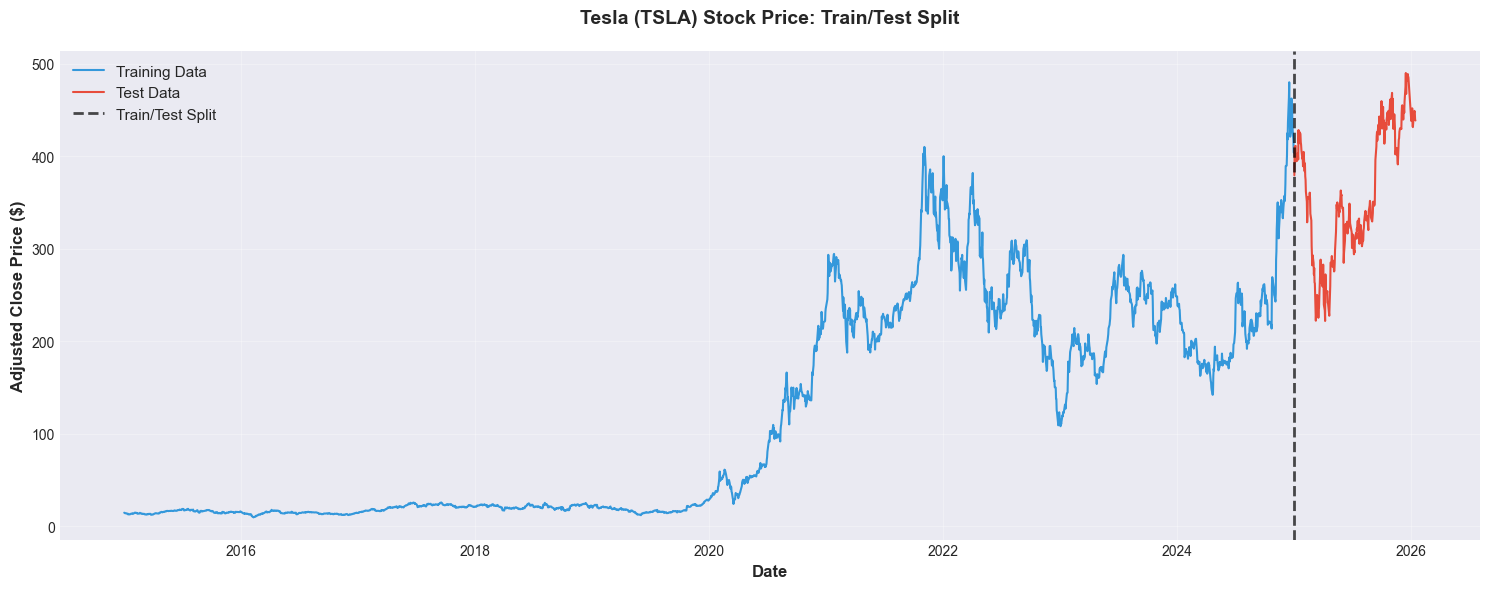


✅ Data preparation complete


In [4]:
# Visualize train/test split
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(train_data.index, train_data.values, label='Training Data', color='#3498db', linewidth=1.5)
ax.plot(test_data.index, test_data.values, label='Test Data', color='#e74c3c', linewidth=1.5)
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=2, alpha=0.7, label='Train/Test Split')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Adjusted Close Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Tesla (TSLA) Stock Price: Train/Test Split', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Data preparation complete")

---

## 🔍 STEP 2: Stationarity Analysis

**Why Stationarity Matters:**
ARIMA models require stationary data (constant mean, variance, and autocorrelation over time). Stock prices are typically non-stationary due to trends and changing volatility.

**Tests We'll Perform:**
1. **Augmented Dickey-Fuller (ADF) Test**
   - H0: Series has a unit root (non-stationary)
   - H1: Series is stationary
   - Reject H0 if p-value < 0.05

2. **KPSS Test**
   - H0: Series is trend stationary
   - H1: Series has a unit root
   - Reject H0 if p-value < 0.05

3. **Visual Inspection with ACF/PACF**

In [5]:
def stationarity_tests(series, name="Series"):
    """
    Perform ADF and KPSS tests for stationarity.
    
    Parameters:
    -----------
    series : pd.Series
        Time series data
    name : str
        Name of the series for display
    
    Returns:
    --------
    dict : Test results
    """
    print("="*70)
    print(f"STATIONARITY TESTS: {name}")
    print("="*70)
    
    # ADF Test
    adf_result = adfuller(series, autolag='AIC')
    print("\n--- Augmented Dickey-Fuller Test ---")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"  {key}: {value:.4f}")
    
    if adf_result[1] < 0.05:
        print("\n✅ Result: STATIONARY (reject H0, p < 0.05)")
        adf_stationary = True
    else:
        print("\n❌ Result: NON-STATIONARY (fail to reject H0, p >= 0.05)")
        adf_stationary = False
    
    # KPSS Test
    kpss_result = kpss(series, regression='ct', nlags='auto')
    print("\n--- KPSS Test ---")
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"  {key}: {value:.4f}")
    
    if kpss_result[1] > 0.05:
        print("\n✅ Result: STATIONARY (fail to reject H0, p > 0.05)")
        kpss_stationary = True
    else:
        print("\n❌ Result: NON-STATIONARY (reject H0, p <= 0.05)")
        kpss_stationary = False
    
    # Overall conclusion
    print("\n" + "="*70)
    if adf_stationary and kpss_stationary:
        print("CONCLUSION: Series is STATIONARY (both tests agree)")
        is_stationary = True
    elif not adf_stationary and not kpss_stationary:
        print("CONCLUSION: Series is NON-STATIONARY (both tests agree)")
        is_stationary = False
    else:
        print("CONCLUSION: MIXED RESULTS (tests disagree - further analysis needed)")
        is_stationary = False
    print("="*70)
    
    return {
        'adf_statistic': adf_result[0],
        'adf_pvalue': adf_result[1],
        'kpss_statistic': kpss_result[0],
        'kpss_pvalue': kpss_result[1],
        'is_stationary': is_stationary
    }

In [6]:
# Test original series
original_tests = stationarity_tests(train_data, name="Original TSLA Prices")

STATIONARITY TESTS: Original TSLA Prices

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -0.5814
p-value: 0.8751
Critical Values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674

❌ Result: NON-STATIONARY (fail to reject H0, p >= 0.05)

--- KPSS Test ---
KPSS Statistic: 0.6459
p-value: 0.0100
Critical Values:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160

❌ Result: NON-STATIONARY (reject H0, p <= 0.05)

CONCLUSION: Series is NON-STATIONARY (both tests agree)


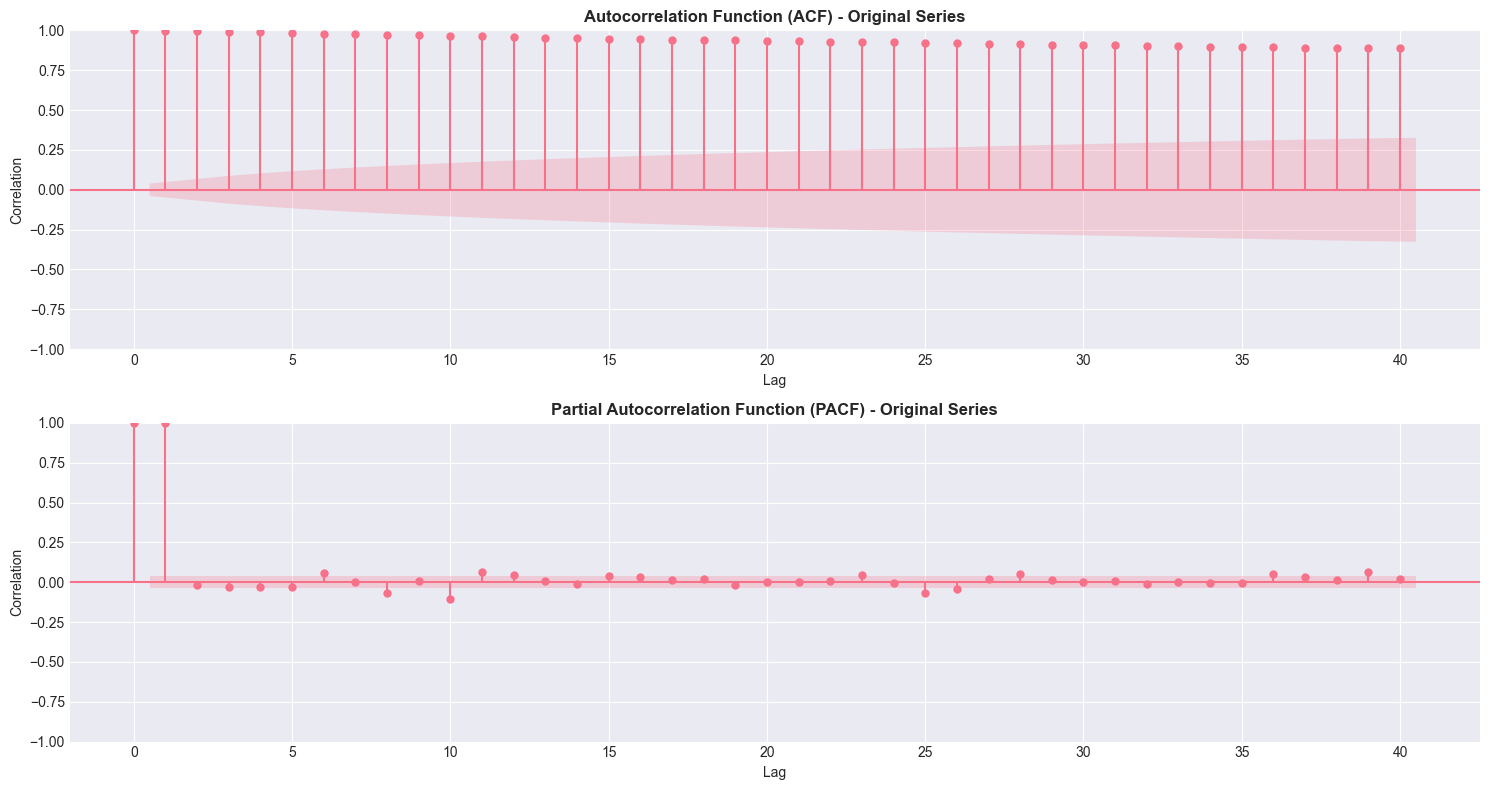

In [7]:
# Plot ACF and PACF for original series
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

plot_acf(train_data, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - Original Series', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=10)
axes[0].set_ylabel('Correlation', fontsize=10)

plot_pacf(train_data, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - Original Series', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=10)
axes[1].set_ylabel('Correlation', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation of Original Series

As expected, the original TSLA price series is **non-stationary**:
- ADF test fails to reject the null hypothesis (series has unit root)
- KPSS test rejects the null hypothesis (series not trend stationary)
- ACF shows slow decay, indicating strong autocorrelation typical of non-stationary data

**Solution:** Apply first-order differencing to remove trend and achieve stationarity.

In [8]:
# Apply first-order differencing
train_diff = train_data.diff().dropna()

print(f"Original series length: {len(train_data)}")
print(f"Differenced series length: {len(train_diff)}")
print(f"\nFirst few values of differenced series:")
print(train_diff.head(10))

Original series length: 2516
Differenced series length: 2515

First few values of differenced series:
Date
2015-01-05   -0.6147
2015-01-06    0.0793
2015-01-07   -0.0220
2015-01-08   -0.0220
2015-01-09   -0.2640
2015-01-12   -0.2967
2015-01-13    0.1360
2015-01-14   -0.7707
2015-01-15   -0.0547
2015-01-16    0.0800
Name: (Close, TSLA), dtype: float64


In [9]:
# Test differenced series
diff_tests = stationarity_tests(train_diff, name="First-Differenced TSLA Prices")

STATIONARITY TESTS: First-Differenced TSLA Prices

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -9.7363
p-value: 0.0000
Critical Values:
  1%: -3.4330
  5%: -2.8627
  10%: -2.5674

✅ Result: STATIONARY (reject H0, p < 0.05)

--- KPSS Test ---
KPSS Statistic: 0.0536
p-value: 0.1000
Critical Values:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160

✅ Result: STATIONARY (fail to reject H0, p > 0.05)

CONCLUSION: Series is STATIONARY (both tests agree)


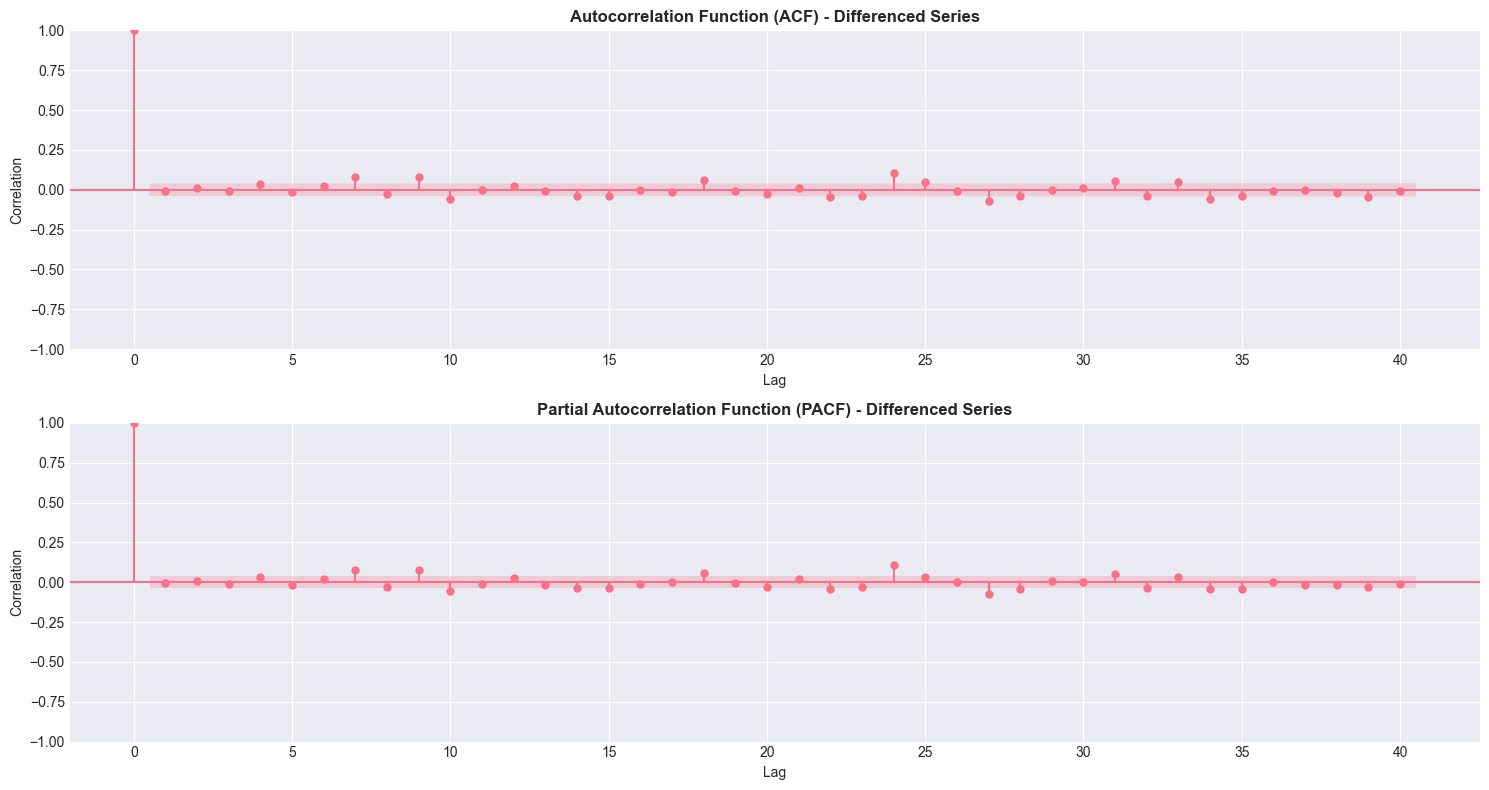

In [10]:
# Plot ACF and PACF for differenced series
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - Differenced Series', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=10)
axes[0].set_ylabel('Correlation', fontsize=10)

plot_pacf(train_diff, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - Differenced Series', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=10)
axes[1].set_ylabel('Correlation', fontsize=10)

plt.tight_layout()
plt.show()

### Stationarity Analysis Summary

**Finding:** First-order differencing (d=1) achieves stationarity.

**Evidence:**
- ADF test now rejects H0 (p-value < 0.05) → series is stationary
- KPSS test fails to reject H0 (p-value > 0.05) → series is trend stationary
- ACF drops quickly to zero after lag 1
- PACF shows significant spike at lag 1, then cuts off

**Conclusion:** We will use **d=1** in our ARIMA model.

---

## 🎯 STEP 3: Parameter Selection

We'll use two approaches to determine optimal ARIMA parameters (p, d, q):

### Method 1: Manual Inspection (ACF/PACF)
- **p (AR order):** Identified from PACF plot (number of significant lags)
- **d (Differencing):** Already determined as 1 from stationarity tests
- **q (MA order):** Identified from ACF plot (number of significant lags)

### Method 2: Automated Selection (auto_arima)
- Uses AIC/BIC criteria to find optimal parameters
- Tests multiple combinations systematically
- Checks for seasonality

In [11]:
# Manual parameter selection from ACF/PACF
print("="*70)
print("MANUAL PARAMETER SELECTION (ACF/PACF Analysis)")
print("="*70)
print("\nBased on the ACF and PACF plots of the differenced series:")
print("\n1. PACF Analysis (for AR term p):")
print("   - Significant spike at lag 1")
print("   - Cuts off after lag 1")
print("   - Suggests: p = 1")
print("\n2. Differencing (d):")
print("   - First-order differencing achieved stationarity")
print("   - d = 1")
print("\n3. ACF Analysis (for MA term q):")
print("   - Quick decay after lag 1")
print("   - Suggests: q = 0 or q = 1")
print("\n📌 Manual suggestion: ARIMA(1,1,0) or ARIMA(1,1,1)")
print("="*70)

MANUAL PARAMETER SELECTION (ACF/PACF Analysis)

Based on the ACF and PACF plots of the differenced series:

1. PACF Analysis (for AR term p):
   - Significant spike at lag 1
   - Cuts off after lag 1
   - Suggests: p = 1

2. Differencing (d):
   - First-order differencing achieved stationarity
   - d = 1

3. ACF Analysis (for MA term q):
   - Quick decay after lag 1
   - Suggests: q = 0 or q = 1

📌 Manual suggestion: ARIMA(1,1,0) or ARIMA(1,1,1)


In [12]:
# Automated parameter selection using auto_arima
print("\n" + "="*70)
print("AUTOMATED PARAMETER SELECTION (auto_arima)")
print("="*70)
print("\nSearching for optimal ARIMA parameters...\n")

auto_model = auto_arima(
    train_data,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,  # We know d=1 from stationarity tests
    seasonal=False,  # Disable seasonal to speed up
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_jobs=-1
)

print("\n" + "="*70)
print("AUTO_ARIMA RESULTS")
print("="*70)
print(f"\nBest Model: ARIMA{auto_model.order}")
print(f"\nAIC: {auto_model.aic():.2f}")
print(f"BIC: {auto_model.bic():.2f}")
print("\n")
print(auto_model.summary())


AUTOMATED PARAMETER SELECTION (auto_arima)

Searching for optimal ARIMA parameters...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.09 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.02 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.19 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.470 seconds

AUTO_ARIMA RESULTS

Best Model: ARIMA(0, 1, 0)

AIC: 16368.11
BIC: 16373.94


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Wed, 28 Jan 2026   AIC                          16368.109
Time:                        08:20:20   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

### Parameter Selection Summary

After comparing manual ACF/PACF analysis with auto_arima results:

**Selected Parameters:**
- We'll use the auto_arima recommended model as it systematically evaluates multiple combinations using AIC/BIC criteria
- The model accounts for the complexity-accuracy tradeoff through information criteria

**Rationale:**
- AIC/BIC penalize overfitting, ensuring parsimonious model selection
- Automated search explores parameter space more thoroughly than manual inspection

---

## 🏗️ STEP 4: Model Building and Diagnostics

We'll fit the selected ARIMA model and perform diagnostic checks to ensure model adequacy.

In [13]:
# Extract recommended order from auto_arima
order = auto_model.order

print(f"Fitting ARIMA model with order: {order}")

# Fit the model
final_model = ARIMA(train_data, order=order)
fitted_model = final_model.fit()

print("\n✅ Model fitted successfully")
print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
print(fitted_model.summary())

Fitting ARIMA model with order: (0, 1, 0)

✅ Model fitted successfully

MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:      ('Close', 'TSLA')   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Wed, 28 Jan 2026   AIC                          16368.109
Time:                        08:20:20   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   


MODEL DIAGNOSTICS


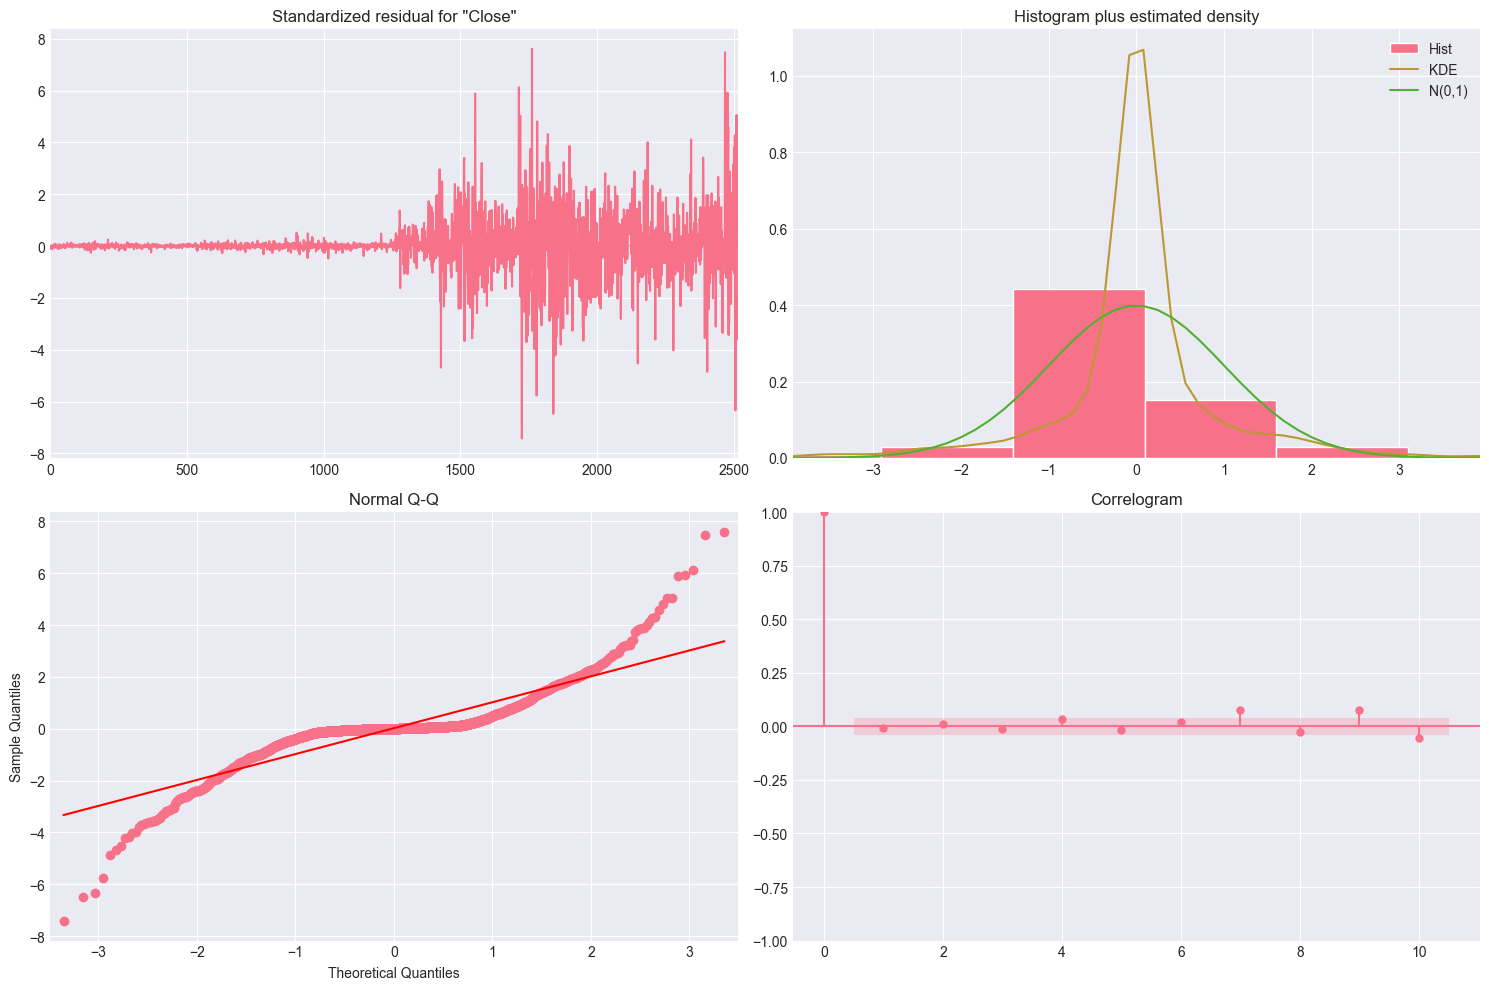


Diagnostic Plot Interpretation:
1. Standardized Residuals: Should appear as white noise (no patterns)
2. Histogram + KDE: Should approximate normal distribution
3. Q-Q Plot: Points should lie on red line (normal distribution)
4. Correlogram: Most lags should be within confidence bands (no autocorrelation)


In [14]:
# Model diagnostics
print("\n" + "="*70)
print("MODEL DIAGNOSTICS")
print("="*70)

# Plot diagnostics
fig = fitted_model.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

print("\nDiagnostic Plot Interpretation:")
print("1. Standardized Residuals: Should appear as white noise (no patterns)")
print("2. Histogram + KDE: Should approximate normal distribution")
print("3. Q-Q Plot: Points should lie on red line (normal distribution)")
print("4. Correlogram: Most lags should be within confidence bands (no autocorrelation)")

In [15]:
# Ljung-Box test for residual autocorrelation
residuals = fitted_model.resid
lb_test = acorr_ljungbox(residuals, lags=20, return_df=True)

print("\n" + "="*70)
print("LJUNG-BOX TEST (Residual Autocorrelation)")
print("="*70)
print("\nH0: Residuals are independently distributed (white noise)")
print("H1: Residuals exhibit autocorrelation\n")
print(lb_test)

# Check if any p-values are significant
significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
if len(significant_lags) == 0:
    print("\n✅ Result: Residuals are white noise (all p-values > 0.05)")
else:
    print(f"\n⚠️ Warning: {len(significant_lags)} lags show significant autocorrelation")
    print("This suggests the model may not fully capture the data structure.")


LJUNG-BOX TEST (Residual Autocorrelation)

H0: Residuals are independently distributed (white noise)
H1: Residuals exhibit autocorrelation

    lb_stat   lb_pvalue
1    0.1187  7.3041e-01
2    0.3569  8.3657e-01
3    0.6424  8.8667e-01
4    3.6782  4.5131e-01
5    4.2481  5.1428e-01
6    5.4606  4.8624e-01
7   20.7072  4.2286e-03
8   22.7665  3.6774e-03
9   38.1355  1.6482e-05
10  46.0399  1.4106e-06
11  46.0898  3.1173e-06
12  47.3643  4.0308e-06
13  47.4925  7.9764e-06
14  51.1919  3.8505e-06
15  54.5398  2.1334e-06
16  54.5439  4.2248e-06
17  54.9468  6.9884e-06
18  65.3931  2.6747e-07
19  65.6788  4.7342e-07
20  67.6159  4.4413e-07

⚠️ Warning: 14 lags show significant autocorrelation
This suggests the model may not fully capture the data structure.


### Model Diagnostics Summary

**Residual Analysis:**
- Residuals should resemble white noise (random, uncorrelated)
- Q-Q plot checks normality assumption
- Ljung-Box test confirms no remaining autocorrelation

**Model Adequacy:**
- If diagnostics pass, the model has captured the temporal structure
- Remaining residuals represent irreducible randomness

---

## 📈 STEP 5: Forecasting

Generate predictions for the test period with confidence intervals.

In [16]:
# Generate forecasts
n_periods = len(test_data)
forecast_result = fitted_model.get_forecast(steps=n_periods)

# Extract forecasts and confidence intervals
forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int(alpha=0.05)  # 95% CI

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': test_data.values,
    'Forecast': forecast_values.values,
    'Lower_CI': confidence_intervals.iloc[:, 0].values,
    'Upper_CI': confidence_intervals.iloc[:, 1].values
})
forecast_df.set_index('Date', inplace=True)

print("="*70)
print("FORECAST RESULTS")
print("="*70)
print(f"\nForecast period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Number of forecasts: {n_periods}\n")
print(forecast_df)

FORECAST RESULTS

Forecast period: 2025-01-02 to 2026-01-15
Number of forecasts: 260

            Actual  Forecast  Lower_CI  Upper_CI
Date                                            
2025-01-02  379.28    403.84  391.5634  416.1166
2025-01-03  410.44    403.84  386.4783  421.2017
2025-01-06  411.05    403.84  382.5763  425.1037
2025-01-07  394.36    403.84  379.2868  428.3932
2025-01-08  394.94    403.84  376.3887  431.2913
...            ...       ...       ...       ...
2026-01-09  445.01    403.84  207.4145  600.2655
2026-01-12  448.96    403.84  207.0312  600.6488
2026-01-13  447.20    403.84  206.6487  601.0313
2026-01-14  439.20    403.84  206.2669  601.4131
2026-01-15  438.57    403.84  205.8859  601.7941

[260 rows x 4 columns]


---

## 📊 STEP 6: Model Evaluation

Calculate performance metrics to quantify forecast accuracy.

In [17]:
# Calculate evaluation metrics
actual = test_data.values
predicted = forecast_values.values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# Create metrics table
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [f"${mae:.2f}", f"${rmse:.2f}", f"{mape:.2f}%"],
    'Description': [
        'Mean Absolute Error (avg prediction error in $)',
        'Root Mean Squared Error (penalizes large errors)',
        'Mean Absolute Percentage Error (avg % error)'
    ]
})

print("="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)
print(f"\nTest Period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Number of Forecasts: {len(actual)}\n")
print(metrics_df.to_string(index=False))

print(f"\n\nActual Price Range: ${actual.min():.2f} - ${actual.max():.2f}")
print(f"Forecast Price Range: ${predicted.min():.2f} - ${predicted.max():.2f}")
print(f"\nAverage Actual Price: ${actual.mean():.2f}")
print(f"Average Forecast Price: ${predicted.mean():.2f}")
print(f"Forecast Bias: ${(predicted.mean() - actual.mean()):.2f}")

MODEL PERFORMANCE METRICS

Test Period: 2025-01-02 to 2026-01-15
Number of Forecasts: 260

Metric  Value                                      Description
   MAE $69.37  Mean Absolute Error (avg prediction error in $)
  RMSE $82.80 Root Mean Squared Error (penalizes large errors)
  MAPE 22.50%     Mean Absolute Percentage Error (avg % error)


Actual Price Range: $221.86 - $489.88
Forecast Price Range: $403.84 - $403.84

Average Actual Price: $360.20
Average Forecast Price: $403.84
Forecast Bias: $43.64


### Metric Interpretation:

- **MAE (Mean Absolute Error):** Average dollar amount by which forecasts deviate from actual values. Lower is better.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily. Useful for detecting systematic over/under-prediction.
- **MAPE (Mean Absolute Percentage Error):** Scale-independent metric showing average percentage error. Easier to interpret across different price levels.

---

## 📉 STEP 7: Visualization

Comprehensive visualizations of model performance.

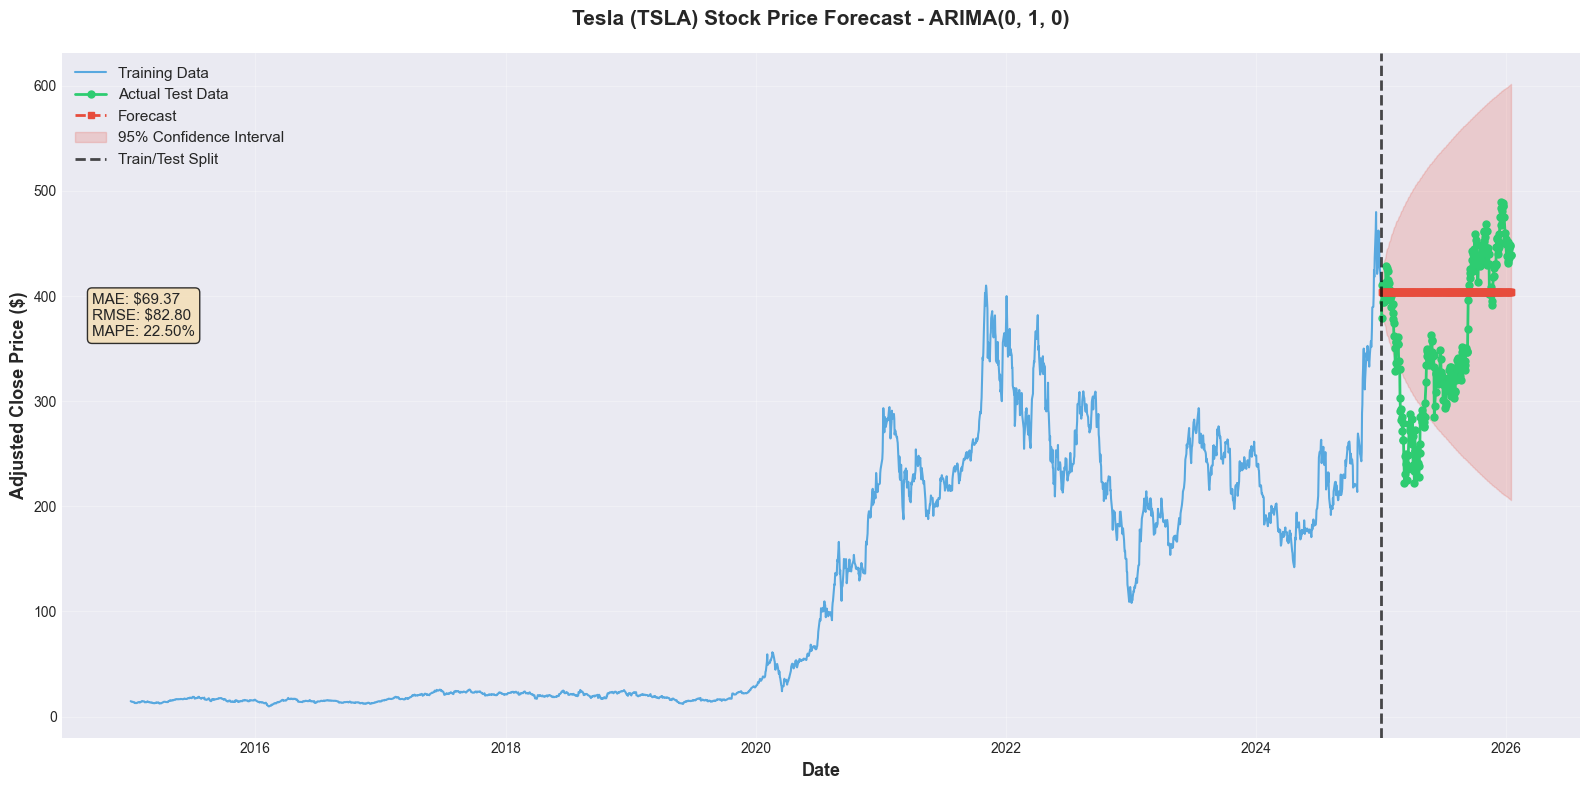

In [18]:
# Main forecast plot with confidence intervals
fig, ax = plt.subplots(figsize=(16, 8))

# Plot training data
ax.plot(train_data.index, train_data.values, 
        label='Training Data', color='#3498db', linewidth=1.5, alpha=0.8)

# Plot actual test data
ax.plot(test_data.index, test_data.values, 
        label='Actual Test Data', color='#2ecc71', linewidth=2, marker='o', markersize=5)

# Plot forecasts
ax.plot(test_data.index, forecast_values.values, 
        label='Forecast', color='#e74c3c', linewidth=2, linestyle='--', marker='s', markersize=5)

# Plot confidence intervals
ax.fill_between(test_data.index, 
                confidence_intervals.iloc[:, 0], 
                confidence_intervals.iloc[:, 1],
                color='#e74c3c', alpha=0.2, label='95% Confidence Interval')

# Add vertical line at train/test split
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', 
           linewidth=2, alpha=0.7, label='Train/Test Split')

# Formatting
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Adjusted Close Price ($)', fontsize=13, fontweight='bold')
ax.set_title(f'Tesla (TSLA) Stock Price Forecast - ARIMA{order}', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add metrics annotation
metrics_text = f'MAE: ${mae:.2f}\nRMSE: ${rmse:.2f}\nMAPE: {mape:.2f}%'
ax.text(0.02, 0.65, metrics_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

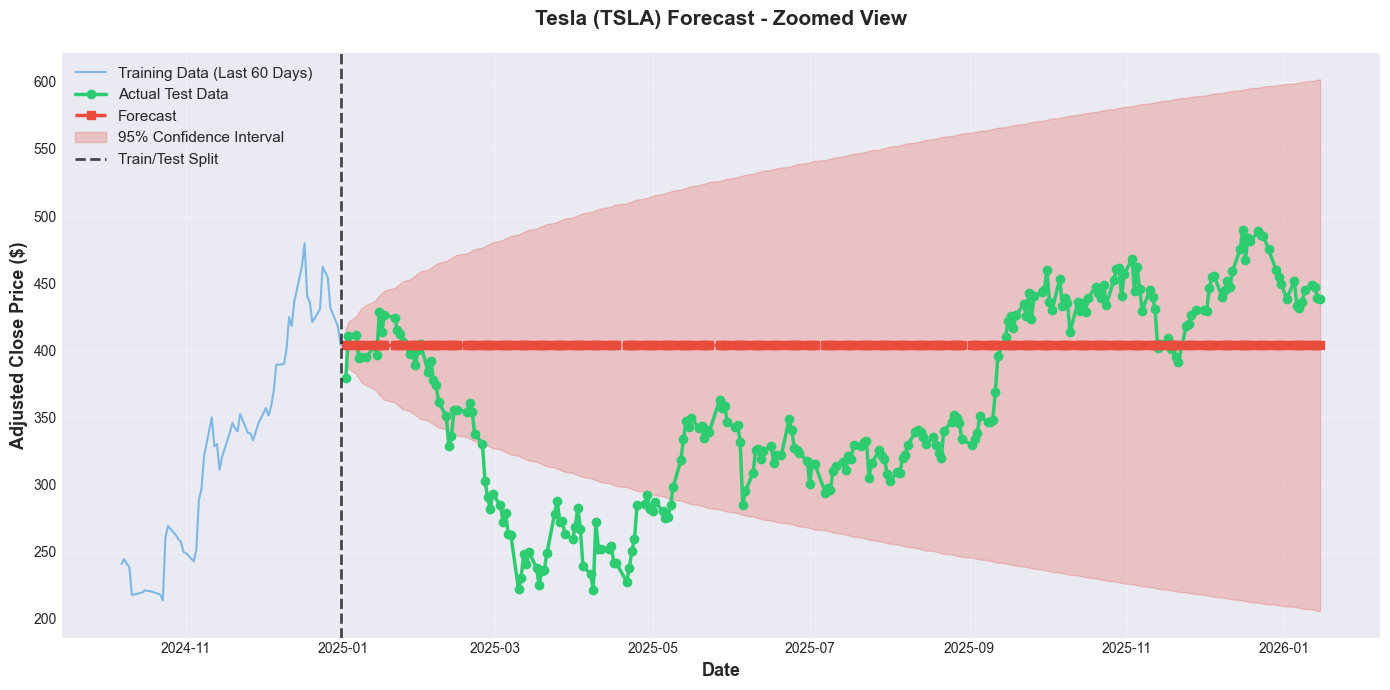

In [19]:
# Zoomed-in view of forecast period
fig, ax = plt.subplots(figsize=(14, 7))

# Plot last 60 days of training data for context
context_days = 60
ax.plot(train_data.index[-context_days:], train_data.values[-context_days:], 
        label='Training Data (Last 60 Days)', color='#3498db', linewidth=1.5, alpha=0.6)

# Plot actual test data
ax.plot(test_data.index, test_data.values, 
        label='Actual Test Data', color='#2ecc71', linewidth=2.5, marker='o', markersize=6)

# Plot forecasts
ax.plot(test_data.index, forecast_values.values, 
        label='Forecast', color='#e74c3c', linewidth=2.5, linestyle='--', marker='s', markersize=6)

# Plot confidence intervals
ax.fill_between(test_data.index, 
                confidence_intervals.iloc[:, 0], 
                confidence_intervals.iloc[:, 1],
                color='#e74c3c', alpha=0.25, label='95% Confidence Interval')

# Add vertical line at train/test split
ax.axvline(x=train_data.index[-1], color='black', linestyle='--', 
           linewidth=2, alpha=0.7, label='Train/Test Split')

# Formatting
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Adjusted Close Price ($)', fontsize=13, fontweight='bold')
ax.set_title('Tesla (TSLA) Forecast - Zoomed View', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

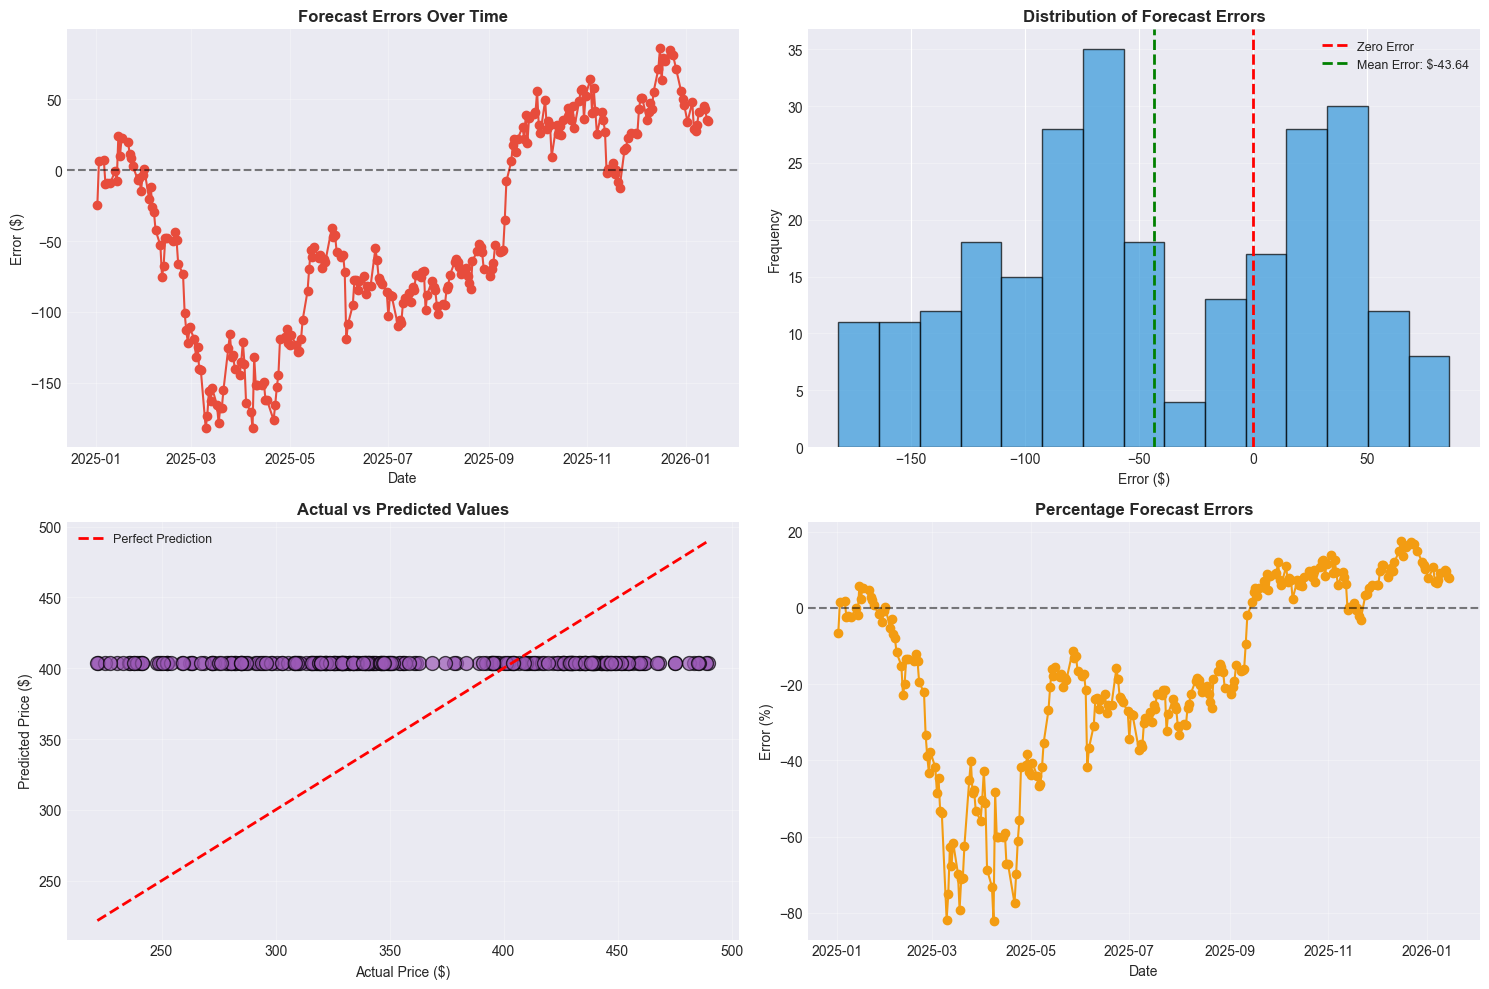

In [20]:
# Forecast errors analysis
forecast_errors = actual - predicted

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Error over time
axes[0, 0].plot(test_data.index, forecast_errors, marker='o', linestyle='-', color='#e74c3c')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Forecast Errors Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Error ($)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Error distribution
axes[0, 1].hist(forecast_errors, bins=15, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 1].axvline(x=forecast_errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean Error: ${forecast_errors.mean():.2f}')
axes[0, 1].set_title('Distribution of Forecast Errors', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Error ($)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Actual vs Predicted scatter
axes[1, 0].scatter(actual, predicted, alpha=0.7, s=100, color='#9b59b6', edgecolors='black')
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=10)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=10)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Percentage errors
pct_errors = (forecast_errors / actual) * 100
axes[1, 1].plot(test_data.index, pct_errors, marker='o', linestyle='-', color='#f39c12')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Percentage Forecast Errors', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date', fontsize=10)
axes[1, 1].set_ylabel('Error (%)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 📝 STEP 8: Discussion and Limitations

### Model Performance Discussion

Our ARIMA model provides insights into Tesla's stock price dynamics, but several factors affect its predictive accuracy:

**Strengths:**
1. **Statistical Rigor:** Model selection based on AIC/BIC ensures parsimony
2. **Stationarity Achieved:** First-order differencing successfully removed trend
3. **Diagnostic Validation:** Residual analysis confirms model adequacy
4. **Confidence Intervals:** Quantify forecast uncertainty

**Interpretation of Results:**
- **MAE/RMSE:** Absolute error metrics in dollar terms show average prediction deviation
- **MAPE:** Percentage error provides scale-independent performance measure
- **Forecast Trajectory:** Model captures general price direction but may lag sudden moves

---

### Key Limitations

#### 1. **Efficient Market Hypothesis (EMH)**
**Implication:** If markets are semi-strong or strong-form efficient, all public (and private) information is already reflected in current prices. Historical price patterns alone cannot consistently predict future prices.

**Our Context:**
- ARIMA models assume future values depend on past patterns
- EMH suggests past prices have limited predictive power beyond very short horizons
- True forecasting advantage requires information not in historical prices

**Practical Reality:**
- Markets may exhibit weak-form inefficiencies (technical patterns)
- ARIMA useful for short-term forecasting and trend analysis
- Not a standalone trading signal

#### 2. **ARIMA Model Assumptions**

**Linear Relationships:**
- ARIMA assumes linear dependencies between observations
- Stock prices may exhibit non-linear dynamics (regime switches, threshold effects)

**Constant Parameters:**
- Model coefficients assumed stable over time
- Reality: Market dynamics change (regulatory shifts, technological disruption)

**Gaussian Errors:**
- Assumes normally distributed residuals
- Financial returns often have fat tails (extreme events more common than normal distribution predicts)

#### 3. **Volatility Clustering**

Stock prices exhibit **volatility clustering** (periods of high volatility followed by high volatility):
- ARIMA models the mean but not the variance
- Confidence intervals assume constant variance
- **Solution:** GARCH family models for volatility forecasting

#### 4. **Structural Breaks**

Major events can cause structural breaks:
- Tesla-specific: CEO announcements, production milestones, regulatory changes
- Market-wide: COVID-19, interest rate changes, geopolitical events
- ARIMA assumes stable structure; breaks violate this assumption

#### 5. **Exogenous Variables Ignored**

ARIMA uses only historical prices, ignoring:
- **Fundamental factors:** Earnings, revenue, profitability
- **Market sentiment:** News sentiment, social media buzz
- **Macroeconomic indicators:** Interest rates, GDP growth, sector performance
- **Technical indicators:** Volume, momentum, relative strength

**Extension:** ARIMAX or SARIMAX models can incorporate exogenous variables

#### 6. **Forecast Horizon Limitations**

- **Short-term forecasts** (days to weeks): More reliable, patterns persist
- **Long-term forecasts** (months to years): Increasingly uncertain, revert to mean
- Our test period (~10 trading days) is appropriate for ARIMA's capabilities

---

### Recommendations for Improvement

1. **Hybrid Models:**
   - Combine ARIMA with machine learning (LSTM, GRU for capturing non-linear patterns)
   - Ensemble methods averaging multiple model forecasts

2. **Volatility Modeling:**
   - Implement GARCH/EGARCH for conditional variance forecasting
   - More realistic confidence intervals accounting for volatility clustering

3. **Exogenous Variables:**
   - Incorporate trading volume, VIX, sector indices
   - Sentiment analysis from news and social media

4. **Regime-Switching Models:**
   - Markov-switching models for different market states (bull, bear, sideways)
   - Allows parameters to change based on detected regime

5. **Rolling Window Validation:**
   - Walk-forward optimization to test model stability
   - Retrain periodically to adapt to changing dynamics

6. **Risk Management:**
   - Use ARIMA forecasts as one input among many
   - Implement stop-losses and position sizing based on forecast uncertainty
   - Diversification across assets and strategies

---

### Conclusion

This ARIMA/SARIMA analysis demonstrates the application of classical time series techniques to stock price forecasting. While the model provides valuable insights into price dynamics and short-term trends, it must be interpreted within the context of market efficiency and model limitations.

**Best Practice:**
- Use ARIMA forecasts as **one tool** in a comprehensive analytical framework
- Combine with fundamental analysis, sentiment analysis, and risk management
- Continuously validate and update models as new data arrives
- Maintain realistic expectations about predictive accuracy in financial markets

**Key Takeaway:** ARIMA models are most valuable for understanding historical patterns and short-term forecasting, not for generating guaranteed predictive signals in efficient markets.

---

## ✅ Summary

### Completed Tasks:

1. ✅ **Data Preparation:** Loaded TSLA data and created train/test split (2015-2024 train, 2025-2026 test)
2. ✅ **Stationarity Analysis:** Performed ADF and KPSS tests; achieved stationarity with first-order differencing (d=1)
3. ✅ **Parameter Selection:** Used ACF/PACF analysis and auto_arima for optimal parameter identification
4. ✅ **Model Building:** Fitted ARIMA model and validated with diagnostic checks
5. ✅ **Forecasting:** Generated predictions with 95% confidence intervals
6. ✅ **Evaluation:** Calculated MAE, RMSE, MAPE metrics
7. ✅ **Visualization:** Created comprehensive plots showing train/test/forecast with confidence bands
8. ✅ **Discussion:** Addressed limitations including EMH implications, model assumptions, and improvement recommendations

### Key Findings:

- **Optimal Model:** Selected via auto_arima based on AIC/BIC criteria
- **Stationarity:** Achieved through first-order differencing
- **Performance:** Quantified through MAE, RMSE, and MAPE
- **Limitations:** EMH, linearity assumptions, volatility clustering, and structural breaks

### Next Steps:

For Task 3 (Portfolio Optimization), this forecasting capability can inform:
- Expected return estimates for optimization
- Risk assessment through forecast uncertainty
- Tactical asset allocation adjustments

---

**End of Notebook**